In [1]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
)
from src.processing import Processing
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import os
import gc
from tfrecordimagehandler import TFRecordImageHandler
from src.datasplitting_for_images import DataSplittingForImages
from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(image_batch, group_name_batch, mouse_id_batches, day_of_study_batches, num_samples=5):
    plt.figure(figsize=(10, num_samples * 3))

    for i in range(num_samples):
        # Primer canal: la imagen en escala de grises
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(np.squeeze(image_batch[i, :, :, 0]), cmap='gray')  # Primer canal
        plt.title(f"Image (Group: {int(group_name_batch[i])}), Mouse: {int(mouse_id_batches[i])}, Day: {int(day_of_study_batches[i])}")
        plt.axis('off')

        # Segundo canal: la máscara
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(np.squeeze(image_batch[i, :, :, 1]), cmap='gray')  # Segundo canal
        plt.title(f"Mask (Group: {int(group_name_batch[i])}), Mouse: {int(mouse_id_batches[i])}, Day: {int(day_of_study_batches[i])}")
        plt.axis('off')

    plt.show()

In [3]:
# Definir hiperparámetros
INPUT_DIR = 'input/tfrecord_dataset'
batch_size = 32
n_epochs = 10
checkpoint = './best_model_vgg.h5'
shuffle = True
verbose = 1

Number of samples: 382
Number of batches: 11
Images min: 0.0, max: 1.0


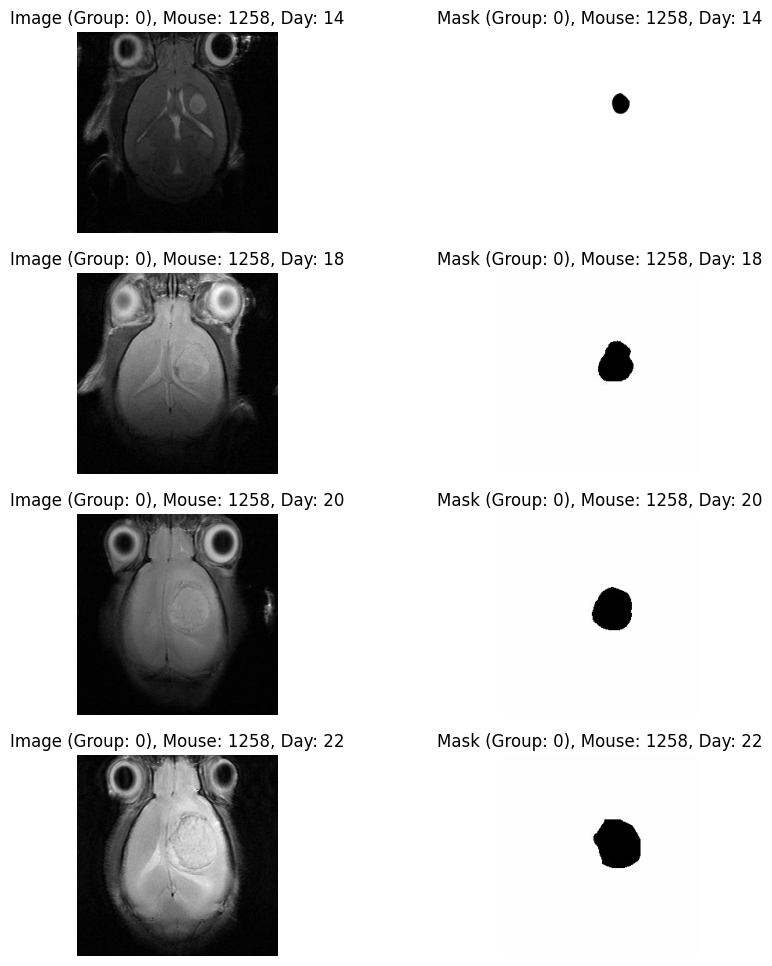

In [4]:
train_tfrefcord = os.path.join(INPUT_DIR, 'full_ds.tfrecord')
ds_handler = TFRecordImageHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
ds = ds_handler.dataset
print(f"Number of samples: {ds_handler.length}")
# Number of batches
n_batches = ds_handler.length // batch_size
print(f"Number of batches: {n_batches}")

#images_tf, masks_tf, group_name_batches, mouse_id_batches, day_of_study_batches = next(iter(train_ds.dataset))

images_tf, group_name_batches, mouse_id_batches, day_of_study_batches = next(iter(ds))
# Check if images are normalized
print(f"Images min: {images_tf.numpy().min()}, max: {images_tf.numpy().max()}")

visualize_data(images_tf, group_name_batches, mouse_id_batches, day_of_study_batches, num_samples=4)
#visualize_data(images_tf, group_name_batches, num_samples=15)

In [5]:
splits = DataSplittingForImages.expanding_window_split(ds)

Day of study: [14. 18. 20. 22. 24. 24. 24.  7.  7. 10. 10. 12. 12. 14. 14. 14. 16. 16.
 16. 16. 18. 18. 18.  8.  8. 10. 14. 16. 16. 18. 18. 20.]
Type: <class 'numpy.ndarray'>
Shape: (32,)
Day of study: [20. 20. 22. 22. 24. 24. 24. 26. 26. 26. 26. 26. 23. 23. 17. 17. 11. 14.
 14. 14. 14. 16. 16. 16. 16. 11. 14. 16. 16. 18. 18. 18.]
Type: <class 'numpy.ndarray'>
Shape: (32,)
Day of study: [20. 20. 20. 20. 22. 22. 22. 22. 11. 14. 16. 16. 16. 18. 18. 18. 20. 20.
 20. 20. 11. 15. 17. 17. 19. 19. 23. 23. 25. 25. 27. 27.]
Type: <class 'numpy.ndarray'>
Shape: (32,)
Day of study: [29. 31. 33. 33. 35. 37. 39. 41. 45. 10. 13. 15. 17. 17. 19. 19. 21. 21.
 23. 23. 27. 10. 13. 15. 17. 19. 21. 23. 27. 15. 15. 17.]
Type: <class 'numpy.ndarray'>
Shape: (32,)
Day of study: [17. 19. 19. 21. 21. 23. 23. 25. 25. 27. 27. 29. 31.  9. 11. 17. 19. 21.
 23. 25. 27. 29. 11. 11. 11. 14. 14. 14. 17. 17. 17. 19.]
Type: <class 'numpy.ndarray'>
Shape: (32,)


ValueError: can only convert an array of size 1 to a Python scalar

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import cv2
import gc

# Cambiar la capa de entrada para aceptar 2 canales
base_model = VGG16(weights='imagenet', include_top=False)
input_layer = layers.Input(shape=(256, 256, 2))
x = layers.Conv2D(3, (1, 1), padding='same', activation='relu')(input_layer)  # Convertir a 3 canales
x = base_model(x)

# Continuar con las capas personalizadas
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output_layer = layers.Dense(2, activation='softmax')(x)

model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

model.summary()

# Oversampling con data augmentation
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    return image, label

def oversample_minority_class(dataset, minority_class=1, factor=2):
    # Separar las clases
    minority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl == minority_class))
    majority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl != minority_class))

    # Aumentar datos de la clase minoritaria
    augmented_minority_ds = minority_ds.map(augment_data)
    for _ in range(factor - 1):
        augmented_minority_ds = augmented_minority_ds.concatenate(minority_ds.map(augment_data))

    # Recombinar y barajar
    balanced_ds = majority_ds.concatenate(augmented_minority_ds)
    return balanced_ds.shuffle(buffer_size=1000)


# Aplicar oversampling al conjunto de datos
ds_balanced = oversample_minority_class(ds, minority_class=1, factor=3)

# Dividir en conjunto de entrenamiento y validación
train_size = int(0.8 * len(list(ds_balanced)))
train_ds = ds_balanced.take(train_size)
val_ds = ds_balanced.skip(train_size)

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Cambia según la codificación de tus etiquetas
    metrics=['accuracy']
)

# Entrenar el modelo
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 256, 256, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 3)    │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,242,059 (58.14 MB)

 Trainable params: 15,242,059 (58.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.6190 - loss: 1.5963 - val_accuracy: 0.5625 - val_loss: 3.2640
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.4566 - loss: 2.0867 - val_accuracy: 0.6562 - val_loss: 0.6474
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.5327 - loss: 0.8318 - val_accuracy: 0.9062 - val_loss: 0.5656
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.6134 - loss: 0.7044 - val_accuracy: 0.6562 - val_loss: 0.6730
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.6396 - loss: 0.6725 - val_accuracy: 0.6508 - val_loss: 0.6601
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.6407 - loss: 0.6662 - val_accuracy: 0.3906 - val_loss: 0.7394
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.7365 - loss: 0.6312 - val_accuracy: 0.5625 - val_loss: 0.6899
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.6703 - loss: 0.6450 - val_accuracy: 0.7344 - val_loss:

ValueError: No such layer: block5_conv3. Existing layers are: ['input_layer_11', 'conv2d', 'vgg16', 'global_average_pooling2d_5', 'dense_10', 'dropout_5', 'dense_11'].

In [17]:
for layer in model.get_layer('vgg16').layers:
    print(layer.name)



input_layer_10
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [19]:
def generate_cam(model, image, class_idx):
    # Nombre de la capa dentro del modelo base
    last_conv_layer_name = 'block5_conv3'  # Ajustar si es necesario
    vgg16_base = model.get_layer('vgg16')  # Obtener el modelo base
    last_conv_layer = vgg16_base.get_layer(last_conv_layer_name)  # Obtener la capa específica

    # Crear un modelo con salida de la capa convolucional y la predicción final
    grad_model = tf.keras.models.Model(
        [model.input], 
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        tape.watch(image)
        conv_output, predictions = grad_model(image)
        class_channel = predictions[:, class_idx]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    cam = np.dot(conv_output, pooled_grads)
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (256, 256))
    cam = cam / cam.max()

    return cam


# Visualizar CAM
sample_image, label = next(iter(val_ds))
sample_image = sample_image[0:1]
class_idx = np.argmax(label[0])
cam = generate_cam(model, sample_image, class_idx)

plt.imshow(sample_image[0])
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title(f'Class {class_idx} - CAM')
plt.show()

# Liberar memoria
del model
gc.collect()
tf.keras.backend.clear_session()

KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m2598520973904\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 256, 256, 2), dtype=float32)\n  • training=None\n  • mask=None'